In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    dbname='postgres',
    user='postgres',
    host='localhost',
    password=input()
)

cur = conn.cursor

query = """SELECT property_state,
        ROUND(SUM(unpaid_principal_balance),2)::NUMERIC AS Total_UPB,
        COUNT(*) AS Total_Loans,
        ROUND(AVG(loan_interest_rate), 2) AS Average_Interest_Rate,
        SUM(CASE WHEN months_delinquent <> 0 THEN 1 ELSE 0 END) AS Total_Delinquent_Loans,
        SUM(CASE WHEN months_delinquent <> 0 THEN unpaid_principal_balance ELSE 0 END) AS Total_Delinquent_UPB
FROM gnma_mbs_mf_loans
GROUP BY property_state
ORDER BY Total_UPB DESC"""

df = pd.read_sql(query, conn)

conn.close()

print(df.head())

  property_state     total_upb  total_loans  average_interest_rate  \
0             TX  4.025909e+10         2745                   3.82   
1             NY  2.322764e+10         1204                   3.96   
2             CA  2.314304e+10         2227                   3.80   
3             FL  1.914556e+10         1213                   4.02   
4             VA  1.511004e+10          821                   3.74   

   total_delinquent_loans  total_delinquent_upb  
0                      15          4.125588e+08  
1                       7          1.780502e+08  
2                       7          7.951033e+07  
3                      12          2.545942e+08  
4                       0          0.000000e+00  


C:\Users\H59045\AppData\Local\Temp\1\ipykernel_1388\1512118375.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [2]:
df['total_upb'] = (df['total_upb']/1000000000).round(2)


Text(0, 0.5, 'Total UPB in Millions')

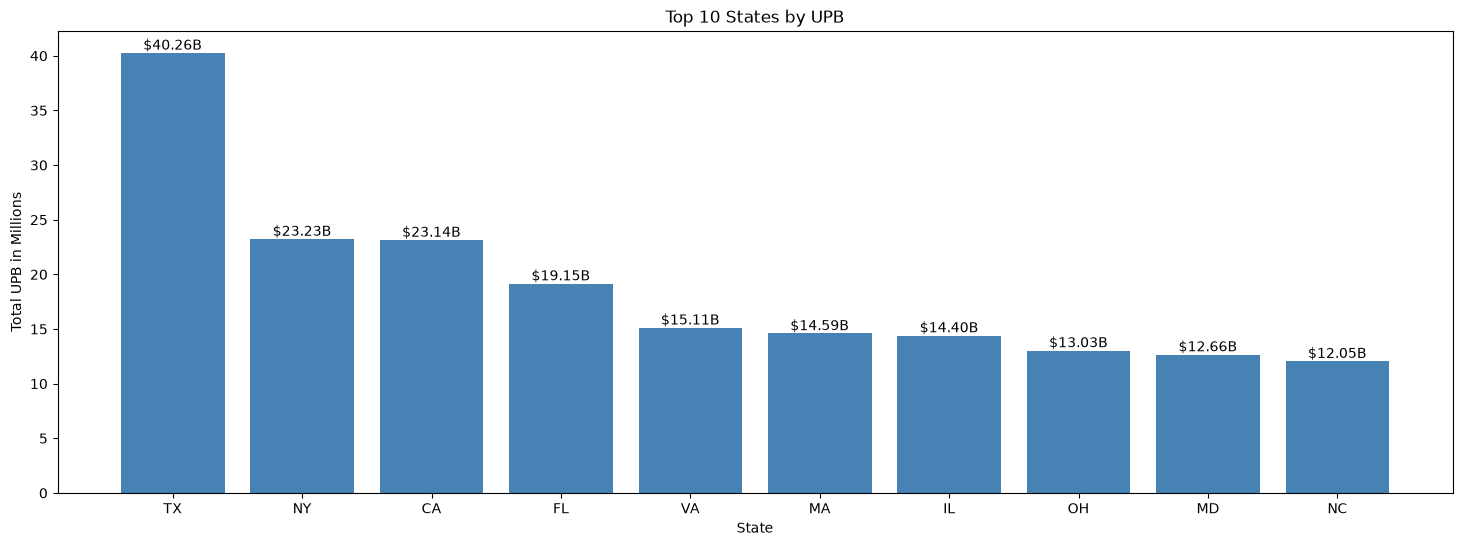

In [3]:

top_states = df.nlargest(10,'total_upb')

plt.figure(figsize=(18,6))
bars = plt.bar(top_states['property_state'], top_states['total_upb'], color='steelblue',)
plt.bar_label(bars, fmt='$%.2fB')
plt.title('Top 10 States by UPB')
plt.xlabel('State')
plt.ylabel('Total UPB in Millions')

Text(0, 0.5, 'Total Delinquencies')

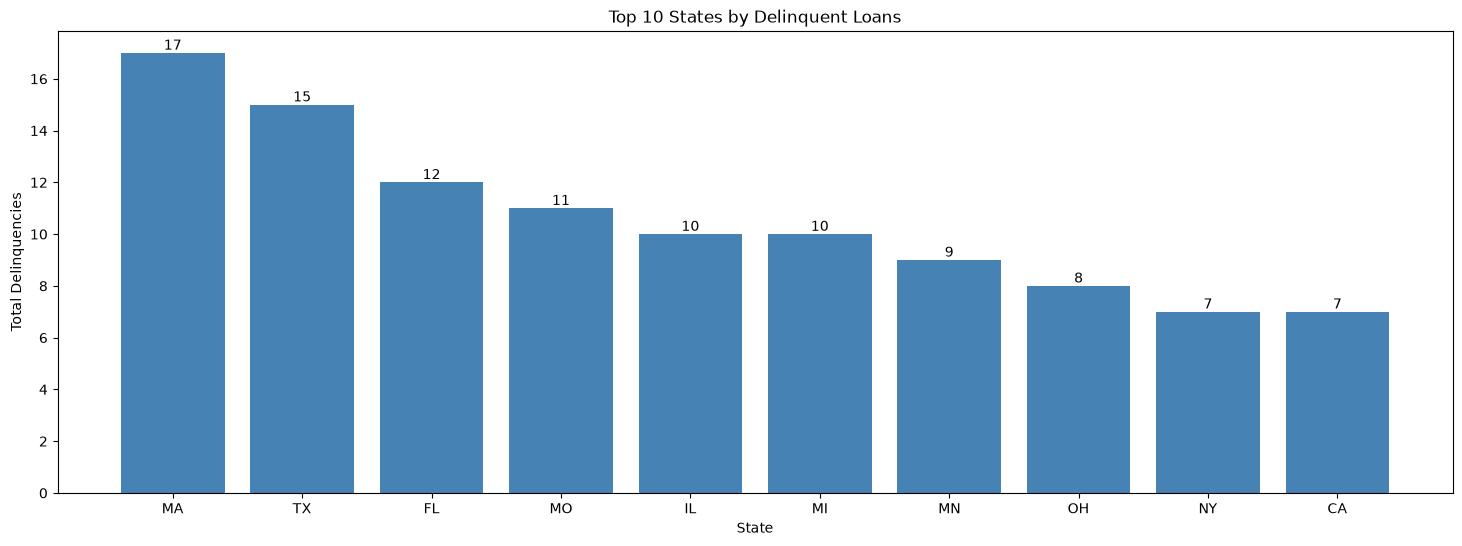

In [4]:
top_states = df.nlargest(10,'total_delinquent_loans')

plt.figure(figsize=(18,6))
bars = plt.bar(top_states['property_state'], top_states['total_delinquent_loans'], color='steelblue',)
plt.bar_label(bars)
plt.title('Top 10 States by Delinquent Loans')
plt.xlabel('State')
plt.ylabel('Total Delinquencies')